In [2]:
#Carga de datos. 
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('../data/Ventas_Analisis.csv', encoding='latin-1') #Usamos encoding ='latin-1' ya que en el archivo hay acentos
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [3]:
#Informacion general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [4]:
#Estadisticas descriptivas
df.describe(include="all")

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823,2823,2823.000000,2823.000000,2823.00000,...,2823,302,2823,1337,2747,2823,1749,2823,2823,2823
unique,NaN,NaN,NaN,NaN,NaN,252,6,NaN,NaN,NaN,...,92,9,73,16,73,19,3,77,72,3
top,NaN,NaN,NaN,NaN,NaN,11/14/2003 0:00,Shipped,NaN,NaN,NaN,...,"C/ Moralzarzal, 86",Level 3,Madrid,CA,28034,USA,EMEA,Freyre,Diego,Medium
freq,NaN,NaN,NaN,NaN,NaN,38,2617,NaN,NaN,NaN,...,259,55,304,416,259,1004,1407,259,259,1384
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,NaN,NaN,2.717676,7.092455,2003.81509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,92.085478,9.741443,20.174277,4.225841,1841.865106,NaN,NaN,1.203878,3.656633,0.69967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,10100.000000,6.000000,26.880000,1.000000,482.130000,NaN,NaN,1.000000,1.000000,2003.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,NaN,NaN,2.000000,4.000000,2003.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,NaN,NaN,3.000000,8.000000,2004.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,NaN,NaN,4.000000,11.000000,2004.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#Preparacion y limpieza basica
# Conversión de fecha a tipo datetime
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

# Crear columna de año para el análisis temporal
df["YEAR"] = df["ORDERDATE"].dt.year

# Revisión rápida de valores nulos
df.isna().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
YEAR                   0
dtype: int64

In [6]:
# Ventas totales
ventas_totales = df["SALES"].sum()
print('Ventas totales = ', ventas_totales)

Ventas totales =  10032628.85


In [7]:
# Ventas por línea de producto
ventas_por_linea = df.groupby("PRODUCTLINE")["SALES"].sum().sort_values(ascending=False)
print(ventas_por_linea)

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64


In [8]:
ventas_por_pais = df.groupby("COUNTRY")["SALES"].sum().sort_values(ascending=False).head(10)
print(ventas_por_pais)

COUNTRY
USA          3627982.83
Spain        1215686.92
France       1110916.52
Australia     630623.10
UK            478880.46
Italy         374674.31
Finland       329581.91
Norway        307463.70
Singapore     288488.41
Denmark       245637.15
Name: SALES, dtype: float64


In [9]:
ventas_por_año = df.groupby("YEAR")["SALES"].sum().sort_values()
print(ventas_por_año)

YEAR
2005    1791486.71
2003    3516979.54
2004    4724162.60
Name: SALES, dtype: float64


Text(0, 0.5, 'Ventas')

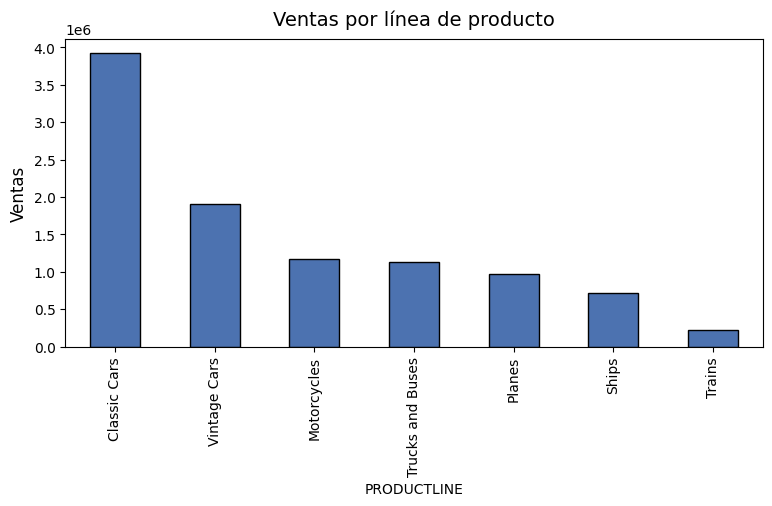

In [10]:
# Ventas por línea de producto
fig, ax = plt.subplots(figsize=(9, 4))

ventas_por_linea.plot(
    kind="bar",
    color="#4C72B0",           # color más agradable
    edgecolor="black"          # borde para distinguir barras
)
ax.set_title("Ventas por línea de producto", fontsize=14, pad=10)
ax.set_ylabel("Ventas", fontsize=12)

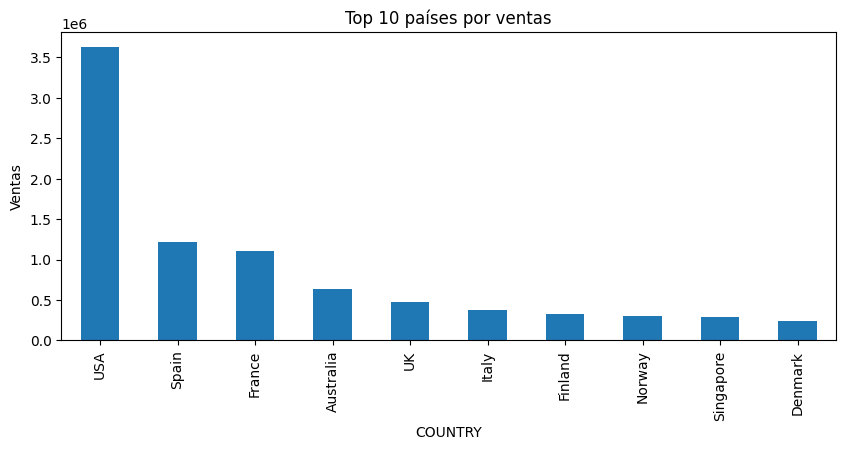

In [11]:
# Top 10 países por ventas
ventas_por_pais.plot(kind="bar", figsize=(10,4), title="Top 10 países por ventas")
plt.ylabel("Ventas")
plt.show()

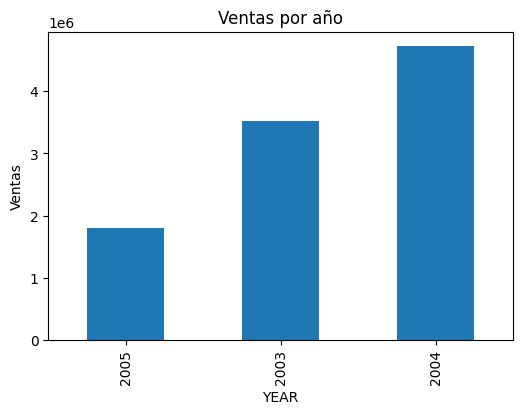

In [12]:
# Ventas por año
ventas_por_año.plot(kind="bar", figsize=(6,4), title="Ventas por año")
plt.ylabel("Ventas")
plt.show()

In [13]:

## Conclusiones de negocio

'''
- Las líneas de producto más importantes por nivel de ventas son **Classic Cars**, seguidas por **Vintage Cars** y **Motorcycles**, lo que indica que el foco principal del catálogo está en autos de colección.
- Estados Unidos concentra la mayor parte de los ingresos, muy por encima del resto de países, mientras que España y Francia destacan como segundos mercados relevantes.
- Australia, Reino Unido e Italia también aportan un volumen interesante de ventas, lo que sugiere una presencia comercial sólida en EMEA y APAC además de Norteamérica.

- A nivel temporal, el año con mayores ventas es 2004, seguido de 2003, mientras que 2005 muestra una caída importante en comparación con los años anteriores.
- Esta caída en 2005 puede indicar un cambio en la demanda, en la estrategia comercial o en la disponibilidad de productos, y sería un punto a investigar con más detalle por el negocio.

- En conjunto, los resultados apuntan a que el área comercial debería:
  - Priorizar campañas y promociones en las líneas **Classic Cars** y **Vintage Cars**.
  - Mantener y reforzar la presencia en Estados Unidos, sin descuidar mercados clave como España, Francia y Australia.
  - Analizar qué ocurrió en 2005 para entender las causas de la caída de ventas y definir acciones correctivas.
  '''


'\n- Las líneas de producto más importantes por nivel de ventas son **Classic Cars**, seguidas por **Vintage Cars** y **Motorcycles**, lo que indica que el foco principal del catálogo está en autos de colección.\n- Estados Unidos concentra la mayor parte de los ingresos, muy por encima del resto de países, mientras que España y Francia destacan como segundos mercados relevantes.\n- Australia, Reino Unido e Italia también aportan un volumen interesante de ventas, lo que sugiere una presencia comercial sólida en EMEA y APAC además de Norteamérica.\n\n- A nivel temporal, el año con mayores ventas es 2004, seguido de 2003, mientras que 2005 muestra una caída importante en comparación con los años anteriores.\n- Esta caída en 2005 puede indicar un cambio en la demanda, en la estrategia comercial o en la disponibilidad de productos, y sería un punto a investigar con más detalle por el negocio.\n\n- En conjunto, los resultados apuntan a que el área comercial debería:\n  - Priorizar campañas y